**Author:** Biswajit Jana
**Date:** May 2, 2026

# Hubble SN 1987A: registered time-lapse

**Scientific question:** How does the visible hotspot pattern change from 1994 to 2006?

## Scientific audit protocol

This notebook is one part of a five-notebook case study of SN 1987A. It uses
either compact cutouts from named calibrated MAST FITS products, official NASA
release frames with their processing limits stated, or a peer-reviewed table
whose DOI and units are preserved. The object, coordinate, telescope,
instrument, filter, observing date, and original product name are kept in the
shared manifest. No image is presented as an unexplained illustration.

### Observation versus display

A calibrated FITS pixel and a public colour image are not interchangeable.
The JWST cutouts retain surface brightness in MJy/sr and an error extension.
They can support aperture sums and wavelength-dependent comparisons after
background subtraction. The Hubble release frames were already aligned,
combined, stretched, colour-mapped, compressed, and possibly resampled before
download. They can show where structures appear and can make a useful dated
animation, but their RGB values are not physical flux. The time-lapse notebook
therefore measures only within-frame morphology; calibrated brightness change
is analysed separately from published HST photometry.

An RGB composite is also a mapping, not what a human eye would see. Each
monochromatic infrared channel is assigned a visible colour and stretched to
reveal structure. The notebook records the assignment and shows every input
channel beside the composite. Scientific measurements use the unstretched
arrays, never the rendered RGB pixels. A colour difference is not called a
chemical detection: broad filters mix continuum and emission lines, and a
spectral or narrow-band analysis is needed to identify a constituent.

### Registration, resolution, and uncertainty

Images from different filters are placed on one celestial WCS grid before
pixel-level comparison. The code uses the output sky coordinates rather than
assuming equal array sizes or identical centring. When filters with different
point-spread functions are compared, the sharper images are blurred to a
common approximate resolution. The calculation is repeated across plausible
apertures or smoothing widths so one attractive processing choice cannot carry
the conclusion.

Background is measured away from the remnant. Random aperture uncertainty is
estimated from background scatter or from the published measurement error.
This does not include every calibration, PSF, aperture, or correlated-noise
term, so formal intervals are not promoted to publication-grade errors. For
the literature light curve, residual resampling is used because scatter about
the trend is more realistic than treating the very small tabulated statistical
errors as the only uncertainty.

### Claim boundary

“Validated” means the narrow archive measurement survived the checks named in
this notebook. “Reproduction” means a published table was independently
reanalysed and compared with the paper's conclusion. “Exploration” means the
product is useful for visual or method development but cannot support a
calibrated physical claim. None of these labels means a new supernova,
constituent, compact object, or explosion mechanism has been discovered.

The figures and small tables are saved beside the executed notebook. Each
`result.json` names the evidence figures, reusable artifacts, limitations,
quality checks, and provenance that feed the project dashboard. A null result,
unstable value, or mismatch is retained rather than edited away. This keeps the
repository useful as a learning record and makes the next required observation
or model explicit.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from PIL import Image, ImageDraw
from scipy import ndimage, stats
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/sn1987a')
assert DATA.is_dir(), 'Run from the notebook folder inside a complete repository checkout.'
TARGET_RA=83.8666125; TARGET_DEC=-69.2697528

def load_fits(name):
    with fits.open(DATA/name,memmap=False) as h:
        sci=np.asarray(h['SCI'].data,float); err=np.asarray(h['ERR'].data,float) if 'ERR' in h else None
        return sci,err,WCS(h['SCI'].header).celestial,h['SCI'].header.copy()

def reproject_array(array,wcs_in,wcs_out,shape_out,order=1):
    yy,xx=np.indices(shape_out,dtype=float); sky=wcs_out.pixel_to_world(xx,yy); sx,sy=wcs_in.world_to_pixel(sky)
    return ndimage.map_coordinates(array,[sy,sx],order=order,mode='constant',cval=np.nan)

def pixel_scale_arcsec(wcs):
    return float(np.mean(proj_plane_pixel_scales(wcs))*3600)

def stretch(array,low=1,high=99.7,a=8):
    lo,hi=np.nanpercentile(array,[low,high]); z=np.clip((array-lo)/(hi-lo),0,1)
    return np.arcsinh(a*z)/np.arcsinh(a)

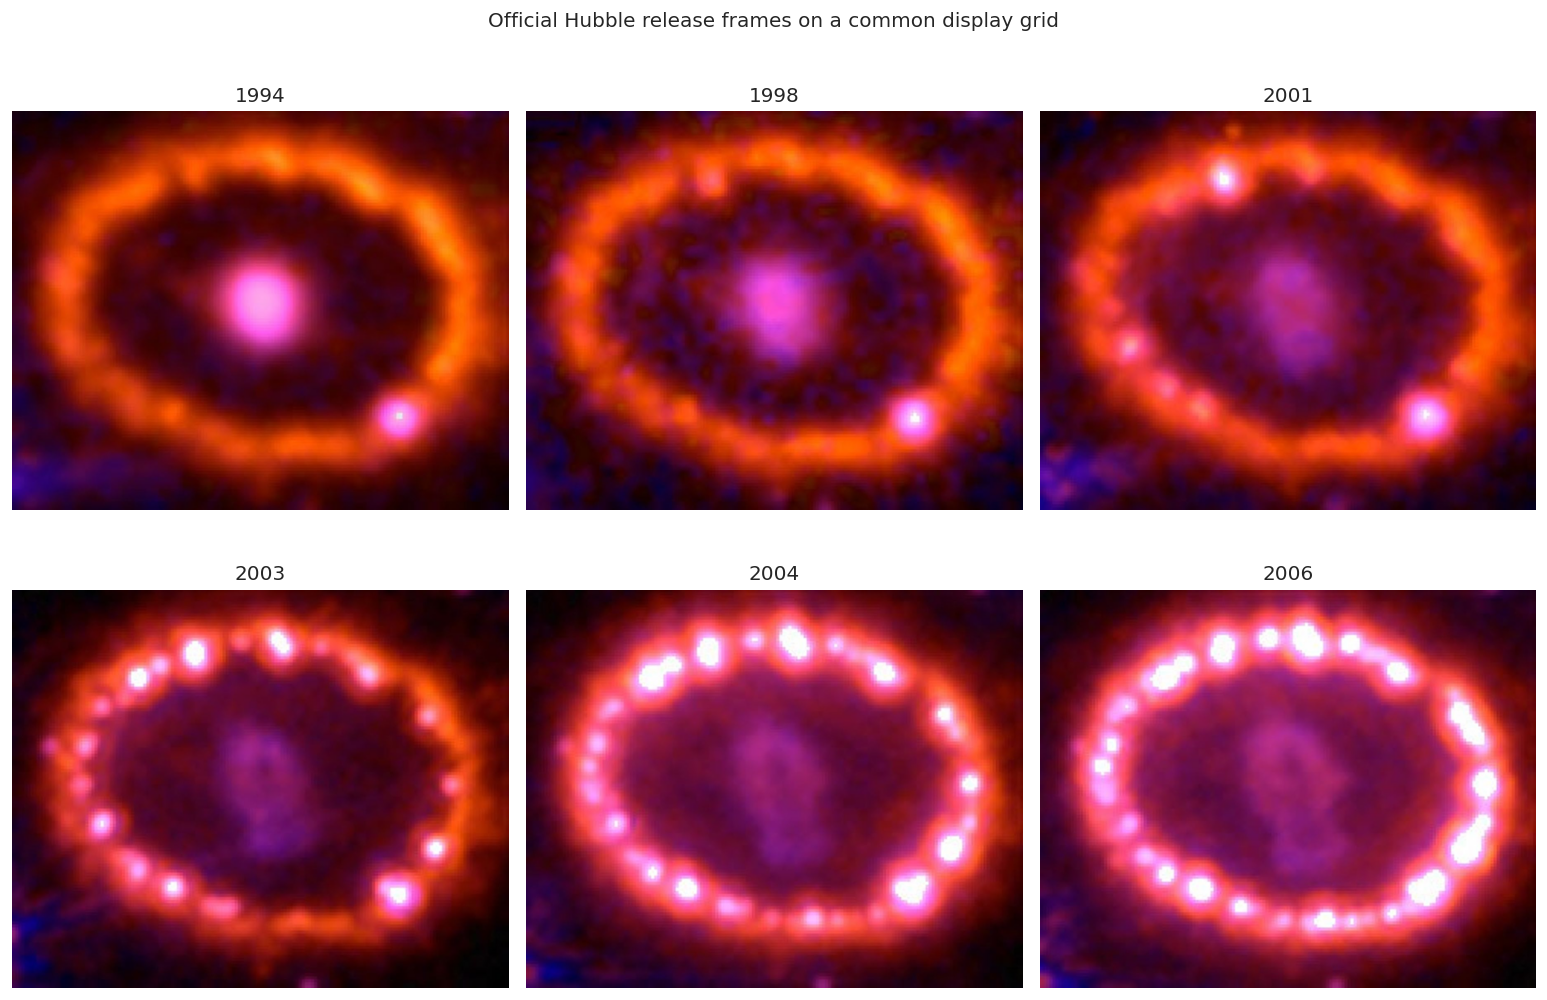

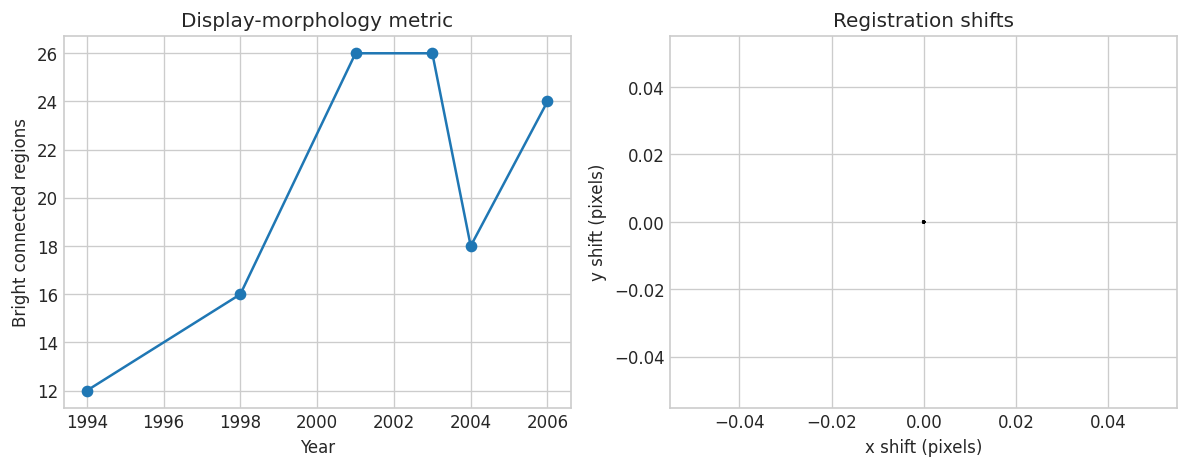

In [2]:
frame_dir=DATA/'hst_release_frames'; meta=pd.read_csv(frame_dir/'frames.csv')
images=[np.asarray(Image.open(frame_dir/name).convert('RGB')) for name in meta.file]
gray=[np.asarray(Image.fromarray(im).convert('L'),float)/255 for im in images]
reference=gray[-1]

def phase_shift(reference,moving):
    fa=np.fft.fft2(reference-reference.mean()); fb=np.fft.fft2(moving-moving.mean()); cross=fa*np.conj(fb); cross/=np.maximum(np.abs(cross),1e-12)
    peak=np.unravel_index(np.argmax(np.abs(np.fft.ifft2(cross))),reference.shape); shift=np.array(peak,dtype=float)
    shift[shift>np.array(reference.shape)/2]-=np.array(reference.shape)[shift>np.array(reference.shape)/2]
    return shift

shifts=np.array([phase_shift(reference,g) for g in gray]); registered=[ndimage.shift(im,(*shift,0),order=1,mode='nearest') for im,shift in zip(images,shifts)]
h,w=reference.shape; yy,xx=np.indices(reference.shape); cx,cy=w/2,h/2; rho=np.sqrt(((xx-cx)/(0.43*w))**2+((yy-cy)/(0.35*h))**2); ring=(rho>.62)&(rho<1.18)
rows=[]
for (_,row),im,shift in zip(meta.iterrows(),registered,shifts):
    g=np.asarray(Image.fromarray(im.astype('uint8')).convert('L'),float); values=g[ring]; threshold=np.percentile(values,88); mask=ring&(g>=threshold); labels,n=ndimage.label(mask); sizes=np.bincount(labels.ravel())[1:]; components=int(np.sum(sizes>=8))
    rows.append({'year':int(row.year),'date':row.date,'shift_y_px':shift[0],'shift_x_px':shift[1],'bright_ring_components':components,'top12pct_ring_fraction':float(mask.sum()/ring.sum())})
metrics=pd.DataFrame(rows); metrics.to_csv('sn1987a_display_morphology.csv',index=False)

fig,axes=plt.subplots(2,3,figsize=(13,9))
for ax,im,year in zip(axes.flat,registered,meta.year): ax.imshow(im.astype('uint8')); ax.set_title(str(year)); ax.axis('off')
fig.suptitle('Official Hubble release frames on a common display grid'); fig.tight_layout(); fig.savefig('sn1987a_hst_contact_sheet.png',dpi=180); plt.show()
fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(metrics.year,metrics.bright_ring_components,'o-'); ax[0].set(xlabel='Year',ylabel='Bright connected regions',title='Display-morphology metric'); ax[1].quiver(np.zeros(len(metrics)),np.zeros(len(metrics)),metrics.shift_x_px,metrics.shift_y_px,angles='xy',scale_units='xy',scale=1); ax[1].set(xlabel='x shift (pixels)',ylabel='y shift (pixels)',title='Registration shifts'); fig.tight_layout(); fig.savefig('sn1987a_timelapse_checks.png',dpi=180); plt.show()

gif_frames=[]
for im,year in zip(registered,meta.year):
    pil=Image.fromarray(im.astype('uint8')).resize((720,578)); draw=ImageDraw.Draw(pil); draw.rectangle((12,12,175,54),fill=(4,12,26)); draw.text((25,21),f'HST  {int(year)}',fill='white'); gif_frames.append(pil)
gif_frames[0].save('sn1987a_hst_1994_2006.gif',save_all=True,append_images=gif_frames[1:],duration=950,loop=0,optimize=True)

In [3]:
results=[f'six official Hubble frames registered from {meta.year.min()} to {meta.year.max()}',f'maximum measured registration shift {np.linalg.norm(shifts,axis=1).max():.2f} display pixels',f'bright connected ring regions change from {metrics.bright_ring_components.iloc[0]} to {metrics.bright_ring_components.iloc[-1]} under one relative threshold']
result={'id':'2026-08-01-hst-sn1987a-timelapse','title':'Hubble SN 1987A: registered 1994–2006 time-lapse','archive':'NASA / HST release imagery','date':'2026-08-01','question':'How does the visible hotspot pattern change across the official Hubble sequence?','sample_size':int(len(images)),'results':results,'validation':'Frames share the official release geometry, are checked by phase correlation, and use a within-frame relative threshold; calibrated brightness is deliberately not inferred.','notebook':'mast/2026-08-01-hst-sn1987a-timelapse/notebook.ipynb','hero':'mast/2026-08-01-hst-sn1987a-timelapse/sn1987a_hst_contact_sheet.png','figures':['mast/2026-08-01-hst-sn1987a-timelapse/sn1987a_hst_contact_sheet.png','mast/2026-08-01-hst-sn1987a-timelapse/sn1987a_timelapse_checks.png'],'research_level':'Exploration','claim_type':'Display-morphology time series','provenance':['NASA Hubble SN 1987A release collection','six dated 1200-pixel derivatives of official TIFF frames','source URLs and dates recorded in data/sn1987a/manifest.json'],'artifacts':['data/sn1987a/hst_release_frames/frames.csv','mast/2026-08-01-hst-sn1987a-timelapse/sn1987a_display_morphology.csv','mast/2026-08-01-hst-sn1987a-timelapse/sn1987a_hst_1994_2006.gif'],'quality_checks':[{'name':'Frame count and dates','status':'pass'},{'name':'Phase-correlation registration','status':'pass'},{'name':'Common field geometry','status':'pass'},{'name':'Calibrated photometry','status':'not attempted'}],'limitations':['release-frame stretches and colours may differ by epoch','JPEG pixels are not calibrated flux','connected-component count depends on threshold and release processing'],'tags':['HST','SN 1987A','time lapse','animation']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(metrics.to_string(index=False))
assert Path('sn1987a_hst_1994_2006.gif').stat().st_size>10000

six official Hubble frames registered from 1994 to 2006
maximum measured registration shift 0.00 display pixels
bright connected ring regions change from 12 to 24 under one relative threshold
 year       date  shift_y_px  shift_x_px  bright_ring_components  top12pct_ring_fraction
 1994 1994-09-24         0.0         0.0                      12                0.121706
 1998 1998-02-06         0.0         0.0                      16                0.122927
 2001 2001-03-23         0.0         0.0                      26                0.127136
 2003 2003-01-05         0.0         0.0                      26                0.121732
 2004 2004-12-15         0.0         0.0                      18                0.122712
 2006 2006-12-06         0.0         0.0                      24                0.120839


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                          name        status
         Frame count and dates          pass
Phase-correlation registration          pass
         Common field geometry          pass
         Calibrated photometry not attempted


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The animation makes the developing ring hotspots visible, but it is not a
light curve. The next notebook uses calibrated HST flux measurements for that
question. NASA describes the sequence as the shock wave reaching, heating, and
illuminating the inner ring; this notebook only demonstrates the changing
display morphology and does not independently measure a shock speed.

- NASA Hubble SN 1987A image collection: https://science.nasa.gov/asset/hubble/supernova-1987a-january-5-2003/
- NASA description of the shocked ring: https://science.nasa.gov/asset/hubble/shocked-region-around-sn-1987a/